In [1]:
# Import necessary libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Load the dataset
df = pd.read_csv("aqi_dataset.csv")
df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,wd,WSPM,AQI,AQI_Category
0,1.0,2013.0,3.0,1.0,0.0,NaN,6.0,13.000000,7.0,300.0,85.0,-2.3,1020.8,-19.7,nw,0.500000,85.0,Satisfactory
1,2.0,2013.0,3.0,1.0,1.0,3.000000,3.0,6.000000,6.0,300.0,85.0,-2.5,1021.3,-19.0,SsE,0.700000,85.0,Satisfactory
2,3.0,2013.0,3.0,8.0,7.0,3.000000,NaN,22.000000,13.0,400.0,74.0,-3.0,1021.3,-19.9,sse,14.954585,74.0,Satisfactory
3,4.0,2013.0,3.0,1.0,3.0,3.000000,6.0,12.000000,8.0,300.0,81.0,-3.6,1021.8,-19.1,nnw,1.000000,81.0,Satisfactory
4,5.0,2013.0,3.0,1.0,7.0,3.000000,3.0,14.000000,8.0,300.0,81.0,-3.5,1022.3,-19.4,nne,2.100000,81.0,Satisfactory
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38652,18119.0,2015.0,3.0,25.0,22.0,125.000000,174.0,22.000000,91.0,1400.0,34.0,11.7,1020.6,0.1,Wnw,1.100000,304.0,Very Poor
38653,NaN,2014.0,11.0,18.0,19.0,-86.801518,199.0,43.000000,97.0,2900.0,7.0,6.6,1019.0,-6.4,Wsw,1.000000,245.0,Poor
38654,24171.0,2015.0,12.0,3.0,2.0,9.000000,NaN,-19.479078,NaN,600.0,25.0,-1.6,1010.8,-15.1,ENE,5.100000,33.0,Good
38655,30287.0,2016.0,8.0,13.0,22.0,795.631575,18.0,2.000000,56.0,700.0,16.0,23.3,997.9,18.6,n,1.500000,70.0,Satisfactory


In [3]:
#BASIC DATA INSPECTION
# structure of dataset
df.info()

# Statistical summary
df.describe()

# Count missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38657 entries, 0 to 38656
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   No            34957 non-null  float64
 1   year          38657 non-null  float64
 2   month         38657 non-null  float64
 3   day           38657 non-null  float64
 4   hour          38657 non-null  float64
 5   PM2.5         33165 non-null  float64
 6   PM10          33329 non-null  float64
 7   SO2           33254 non-null  float64
 8   NO2           33226 non-null  float64
 9   CO            32409 non-null  float64
 10  O3            33260 non-null  float64
 11  TEMP          36691 non-null  float64
 12  PRES          36680 non-null  float64
 13  DEWP          36714 non-null  float64
 14  wd            38657 non-null  object 
 15  WSPM          36723 non-null  float64
 16  AQI           38212 non-null  float64
 17  AQI_Category  38212 non-null  object 
dtypes: float64(16), object(2)


No              3700
year               0
month              0
day                0
hour               0
PM2.5           5492
PM10            5328
SO2             5403
NO2             5431
CO              6248
O3              5397
TEMP            1966
PRES            1977
DEWP            1943
wd                 0
WSPM            1934
AQI              445
AQI_Category     445
dtype: int64

In [4]:
#DROP USELESS COLUMN

df.drop(columns=['No','year','month','day','hour'], inplace=True)

In [5]:
# HANDLE MISSING VALUES 

df['PM2.5'].fillna(df['PM2.5'].median(), inplace=True)

df['PM10'].fillna(df['PM10'].median(), inplace=True)

df['SO2'].fillna(df['SO2'].mean(), inplace=True)

df['NO2'].fillna(df['NO2'].median(), inplace=True)

df['CO'].fillna(df['CO'].mean(), inplace=True)

df['O3'].fillna(df['O3'].median(), inplace=True)

df['TEMP'].fillna(df['TEMP'].mean(), inplace=True)

df['PRES'].fillna(df['PRES'].mean(), inplace=True)

df['DEWP'].fillna(df['DEWP'].mean(), inplace=True)

df['WSPM'].fillna(df['WSPM'].mean(), inplace=True)

In [6]:
df

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,wd,WSPM,AQI,AQI_Category
0,46.000000,6.0,13.000000,7.0,300.0,85.0,-2.3,1020.8,-19.7,nw,0.500000,85.0,Satisfactory
1,3.000000,3.0,6.000000,6.0,300.0,85.0,-2.5,1021.3,-19.0,SsE,0.700000,85.0,Satisfactory
2,3.000000,72.0,22.000000,13.0,400.0,74.0,-3.0,1021.3,-19.9,sse,14.954585,74.0,Satisfactory
3,3.000000,6.0,12.000000,8.0,300.0,81.0,-3.6,1021.8,-19.1,nnw,1.000000,81.0,Satisfactory
4,3.000000,3.0,14.000000,8.0,300.0,81.0,-3.5,1022.3,-19.4,nne,2.100000,81.0,Satisfactory
...,...,...,...,...,...,...,...,...,...,...,...,...,...
38652,125.000000,174.0,22.000000,91.0,1400.0,34.0,11.7,1020.6,0.1,Wnw,1.100000,304.0,Very Poor
38653,-86.801518,199.0,43.000000,97.0,2900.0,7.0,6.6,1019.0,-6.4,Wsw,1.000000,245.0,Poor
38654,9.000000,72.0,-19.479078,36.0,600.0,25.0,-1.6,1010.8,-15.1,ENE,5.100000,33.0,Good
38655,795.631575,18.0,2.000000,56.0,700.0,16.0,23.3,997.9,18.6,n,1.500000,70.0,Satisfactory


In [7]:
# FIX INCONSISTENT DATA

df['wd'] = df['wd'].str.upper()

In [8]:
# REMOVE DUPLICATES

df.drop_duplicates(inplace=True)

In [9]:
df

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,wd,WSPM,AQI,AQI_Category
0,46.000000,6.0,13.000000,7.0,300.000000,85.0,-2.3,1020.8,-19.7,NW,0.500000,85.0,Satisfactory
1,3.000000,3.0,6.000000,6.0,300.000000,85.0,-2.5,1021.3,-19.0,SSE,0.700000,85.0,Satisfactory
2,3.000000,72.0,22.000000,13.0,400.000000,74.0,-3.0,1021.3,-19.9,SSE,14.954585,74.0,Satisfactory
3,3.000000,6.0,12.000000,8.0,300.000000,81.0,-3.6,1021.8,-19.1,NNW,1.000000,81.0,Satisfactory
4,3.000000,3.0,14.000000,8.0,300.000000,81.0,-3.5,1022.3,-19.4,NNE,2.100000,81.0,Satisfactory
...,...,...,...,...,...,...,...,...,...,...,...,...,...
38651,107.000000,130.0,18.587651,26.0,1330.449292,182.0,30.7,992.7,20.3,E,2.700000,256.0,Poor
38652,125.000000,174.0,22.000000,91.0,1400.000000,34.0,11.7,1020.6,0.1,WNW,1.100000,304.0,Very Poor
38653,-86.801518,199.0,43.000000,97.0,2900.000000,7.0,6.6,1019.0,-6.4,WSW,1.000000,245.0,Poor
38654,9.000000,72.0,-19.479078,36.0,600.000000,25.0,-1.6,1010.8,-15.1,ENE,5.100000,33.0,Good


In [10]:
# Handle outliers in PM2.5 using IQR

Q1 = df['PM2.5'].quantile(0.25)
Q3 = df['PM2.5'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['PM2.5'] >= lower) & (df['PM2.5'] <= upper)]

In [11]:
# Handle outliers in PM10

Q1 = df['PM10'].quantile(0.25)
Q3 = df['PM10'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['PM10'] >= lower) & (df['PM10'] <= upper)]

In [12]:
# Handle outliers in SO2

Q1 = df['SO2'].quantile(0.25)
Q3 = df['SO2'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['SO2'] >= lower) & (df['SO2'] <= upper)]

In [13]:
# Handle outliers in NO2

Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['NO2'] >= lower) & (df['NO2'] <= upper)]

In [14]:
# Handle outliers in CO

Q1 = df['CO'].quantile(0.25)
Q3 = df['CO'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['CO'] >= lower) & (df['CO'] <= upper)]

In [15]:
# Handle outliers in O3

Q1 = df['O3'].quantile(0.25)
Q3 = df['O3'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['O3'] >= lower) & (df['O3'] <= upper)]

In [16]:
# Handle outliers in TEMP

Q1 = df['TEMP'].quantile(0.25)
Q3 = df['TEMP'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['TEMP'] >= lower) & (df['TEMP'] <= upper)]

In [17]:
# Handle outliers in PRES

Q1 = df['PRES'].quantile(0.25)
Q3 = df['PRES'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['PRES'] >= lower) & (df['PRES'] <= upper)]

In [18]:
# Handle outliers in DEWP

Q1 = df['DEWP'].quantile(0.25)
Q3 = df['DEWP'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['DEWP'] >= lower) & (df['DEWP'] <= upper)]

In [19]:
# Handle outliers in WSPM

Q1 = df['WSPM'].quantile(0.25)
Q3 = df['WSPM'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['WSPM'] >= lower) & (df['WSPM'] <= upper)]

In [20]:
df.rename(columns={
    'DEWP': 'Humidity',   
    'RAIN': 'Rainfall',
    'WSPM': 'WindSpeed',
    'wd': 'WindDirection'
}, inplace=True)

In [21]:
df

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,Humidity,WindDirection,WindSpeed,AQI,AQI_Category
0,46.0,6.0,13.000000,7.0,300.000000,85.0,-2.3,1020.800000,-19.700000,NW,0.5,85.0,Satisfactory
1,3.0,3.0,6.000000,6.0,300.000000,85.0,-2.5,1021.300000,-19.000000,SSE,0.7,85.0,Satisfactory
3,3.0,6.0,12.000000,8.0,300.000000,81.0,-3.6,1021.800000,-19.100000,NNW,1.0,81.0,Satisfactory
4,3.0,3.0,14.000000,8.0,300.000000,81.0,-3.5,1022.300000,-19.400000,NNE,2.1,81.0,Satisfactory
5,46.0,3.0,10.000000,17.0,400.000000,71.0,-4.5,1022.600000,-19.500000,N,1.7,71.0,Satisfactory
...,...,...,...,...,...,...,...,...,...,...,...,...,...
38638,59.0,59.0,18.587651,10.0,600.000000,22.0,22.5,998.300000,21.800000,SW,0.6,98.0,Satisfactory
38641,21.0,21.0,2.000000,38.0,1330.449292,17.0,9.4,1009.880803,6.300000,ENE,1.5,48.0,Good
38642,46.0,39.0,34.000000,37.0,700.000000,35.0,4.6,1016.800000,-11.900000,NW,0.5,46.0,Good
38645,22.0,23.0,4.000000,36.0,400.000000,46.0,17.4,1015.100000,4.513626,WSW,2.0,123.0,Moderate


In [22]:
# Fix negative values using absolute function

cols = ['PM2.5','PM10','SO2','NO2','CO','O3',
        'TEMP','PRES','Humidity','WindSpeed']

for col in cols:
    df[col] = abs(df[col])

In [23]:
#Adding AQI Category Column

aqi_category = []

for i in df['AQI']:
    if pd.isna(i):
        aqi_category.append(None)
    elif i <= 50:
        aqi_category.append('Good')
    elif i <= 100:
        aqi_category.append('Satisfactory')
    elif i <= 200:
        aqi_category.append('Moderate')
    elif i <= 300:
        aqi_category.append('Poor')
    elif i <= 400:
        aqi_category.append('Very Poor')
    else:
        aqi_category.append('Severe')

df['AQI_Category'] = aqi_category

In [24]:
df

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,Humidity,WindDirection,WindSpeed,AQI,AQI_Category
0,46.0,6.0,13.000000,7.0,300.000000,85.0,2.3,1020.800000,19.700000,NW,0.5,85.0,Satisfactory
1,3.0,3.0,6.000000,6.0,300.000000,85.0,2.5,1021.300000,19.000000,SSE,0.7,85.0,Satisfactory
3,3.0,6.0,12.000000,8.0,300.000000,81.0,3.6,1021.800000,19.100000,NNW,1.0,81.0,Satisfactory
4,3.0,3.0,14.000000,8.0,300.000000,81.0,3.5,1022.300000,19.400000,NNE,2.1,81.0,Satisfactory
5,46.0,3.0,10.000000,17.0,400.000000,71.0,4.5,1022.600000,19.500000,N,1.7,71.0,Satisfactory
...,...,...,...,...,...,...,...,...,...,...,...,...,...
38638,59.0,59.0,18.587651,10.0,600.000000,22.0,22.5,998.300000,21.800000,SW,0.6,98.0,Satisfactory
38641,21.0,21.0,2.000000,38.0,1330.449292,17.0,9.4,1009.880803,6.300000,ENE,1.5,48.0,Good
38642,46.0,39.0,34.000000,37.0,700.000000,35.0,4.6,1016.800000,11.900000,NW,0.5,46.0,Good
38645,22.0,23.0,4.000000,36.0,400.000000,46.0,17.4,1015.100000,4.513626,WSW,2.0,123.0,Moderate


In [25]:
df.to_csv("cleaned_aqi_dataset.csv")

In [26]:
#Standardization

from sklearn.preprocessing import StandardScaler

cols = ['PM2.5','PM10','SO2','NO2','CO','O3',
        'TEMP','PRES','Humidity','WindSpeed']

scaler = StandardScaler()
df[cols] = scaler.fit_transform(df[cols])

In [27]:
df

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,Humidity,WindDirection,WindSpeed,AQI,AQI_Category
0,-0.045104,-1.393819,0.263267,-1.600605,-1.213525,1.009519,-1.434223,1.357767,1.132839,NW,-1.258817,85.0,Satisfactory
1,-1.168025,-1.462171,-0.486830,-1.654670,-1.213525,1.009519,-1.412498,1.408229,1.029511,SSE,-1.045761,85.0,Satisfactory
3,-1.168025,-1.393819,0.156110,-1.546540,-1.213525,0.891008,-1.293008,1.458690,1.044272,NNW,-0.726176,81.0,Satisfactory
4,-1.168025,-1.462171,0.370423,-1.546540,-1.213525,0.891008,-1.303871,1.509151,1.088555,NNE,0.445635,81.0,Satisfactory
5,-0.045104,-1.462171,-0.058203,-1.059952,-1.011101,0.594729,-1.195243,1.539428,1.103317,N,0.019522,71.0,Satisfactory
...,...,...,...,...,...,...,...,...,...,...,...,...,...
38638,0.294384,-0.186273,0.862021,-1.438409,-0.606254,-0.857036,0.760050,-0.912990,1.442825,SW,-1.152289,98.0,Satisfactory
38641,-0.697965,-1.052061,-0.915457,0.075419,0.872347,-1.005175,-0.662969,0.255774,-0.845165,ENE,-0.193535,48.0,Good
38642,-0.045104,-0.641951,2.513556,0.021354,-0.403831,-0.471874,-1.184380,0.954077,-0.018536,NW,-1.258817,46.0,Good
38645,-0.671850,-1.006493,-0.701143,-0.032712,-1.011101,-0.145967,0.206050,0.782509,-1.108855,WSW,0.339106,123.0,Moderate


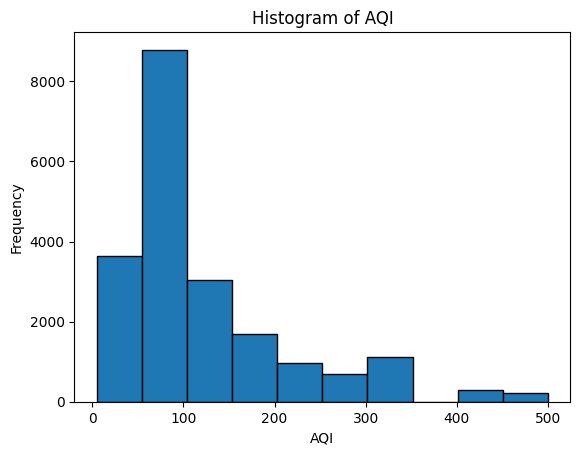

In [28]:
#Histogram for AQI

plt.hist(df['AQI'],edgecolor='black')
plt.title('Histogram of AQI')
plt.xlabel('AQI')
plt.ylabel('Frequency')
plt.show()

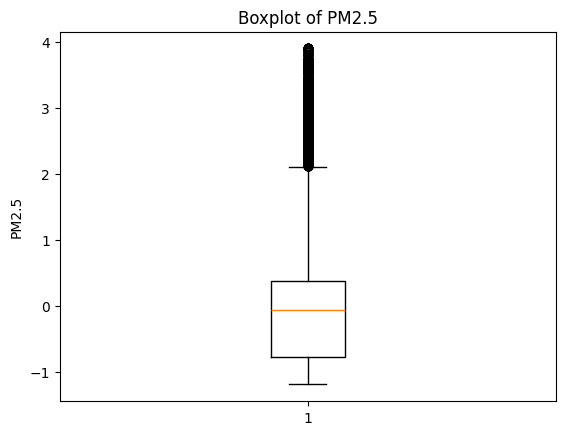

In [29]:
#Box plot for PM2.5
plt.boxplot(df['PM2.5'])
plt.title('Boxplot of PM2.5')
plt.ylabel('PM2.5')
plt.show()

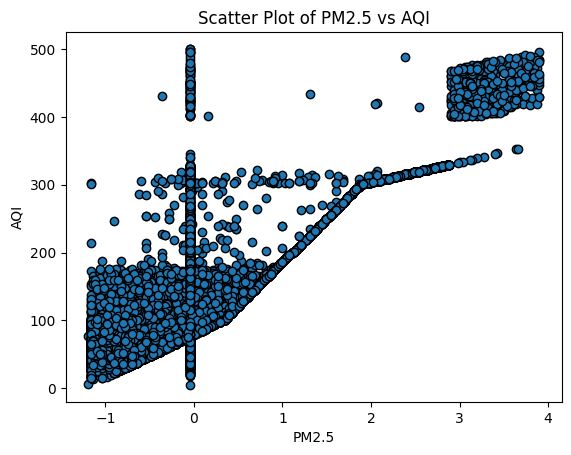

In [30]:
#Scatter plot between PM2.5 and AQI

plt.scatter(df['PM2.5'], df['AQI'],edgecolors="Black")
plt.title('Scatter Plot of PM2.5 vs AQI')
plt.xlabel('PM2.5')
plt.ylabel('AQI')
plt.show()